# Convolutional Neural Networks (CNNs) – Practical Tutorial on MNIST

**Goal:**  
- Understand the key building blocks of CNNs (convolution, pooling, activation, fully connected layers).  
- Implement and train a CNN on the MNIST handwritten digits dataset using PyTorch.  
- Evaluate performance and visualize some predictions.

**Requirements:**  
- Python 3.x  
- PyTorch, torchvision, matplotlib

In [ ]:
# !pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

### MNIST Dataset

MNIST consists of 70,000 grayscale images of handwritten digits (0–9), each of size 28×28 pixels.  
We will use 60,000 images for training and 10,000 for testing via `torchvision.datasets.MNIST`.

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),                 # Converts H×W×C [0,255] to C×H×W [0,1]
    transforms.Normalize((0.1307,), (0.3081,))  # Standard MNIST normalization[web:3]
])

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

batch_size = 64

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

len(train_dataset), len(test_dataset)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.98MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.75MB/s]


(60000, 10000)

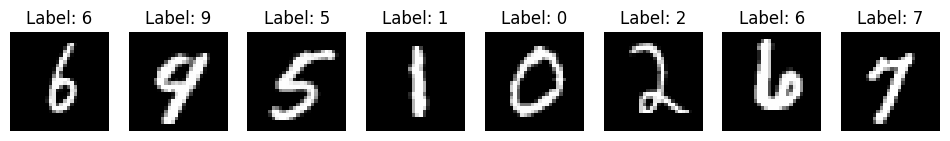

In [ ]:
def show_batch(images, labels, n=8):
    images = images[:n]
    labels = labels[:n]
    images = images.squeeze(1).numpy()  # B×28×28

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i+1)
        plt.imshow(images[i], cmap="gray")
        plt.title(f"Label: {labels[i].item()}")
        plt.axis("off")
    plt.show()

images, labels = next(iter(train_loader))
show_batch(images, labels)

### What is a CNN?

A CNN is a neural network specialized for grid-like data (such as images) using three main ideas:
- **Convolution layers:** Learn small filters (kernels) that slide over the image to detect local features (edges, corners, textures).
- **Pooling layers:** Downsample feature maps (e.g., max pooling) to make representations smaller and more robust to small translations.
- **Fully connected layers:** Use the high-level features to perform classification at the end.

### CNN Architecture for MNIST

We will implement a small architecture inspired by common MNIST CNN examples:

- Conv1: 1 input channel → 16 output channels, kernel size 3, padding 1  
- ReLU + MaxPool (2×2)  
- Conv2: 16 → 32 channels, kernel size 3, padding 1  
- ReLU + MaxPool (2×2)  
- Flatten  
- FC1: 32 × 7 × 7 → 128  
- ReLU + Dropout  
- FC2: 128 → 10 (digits 0–9)

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Input: 1×28×28
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)  # halves H and W[web:7]
        self.dropout = nn.Dropout(0.25)

        # After two 2×2 pools: 28→14→7, so feature map is 32×7×7
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Block 1: conv → relu → pool
        x = self.pool(F.relu(self.conv1(x)))
        # Block 2: conv → relu → pool
        x = self.pool(F.relu(self.conv2(x)))
        # Flatten
        x = x.view(x.size(0), -1)
        # Fully connected
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)  # logits
        return x

model = SimpleCNN().to(device)
model


SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

### Loss Function and Optimizer

For multi-class classification, we use **cross-entropy loss** and the **Adam optimizer**.
We will train for a few epochs and track training and test accuracy.

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


In [ ]:
num_epochs = 5

train_losses, train_accs = [], []
test_losses, test_accs = [], []

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc*100:.2f}% "
          f"| Test Loss: {test_loss:.4f} | Test Acc: {test_acc*100:.2f}%")


Epoch [1/5] Train Loss: 0.1873 | Train Acc: 94.34% | Test Loss: 0.0434 | Test Acc: 98.52%
Epoch [2/5] Train Loss: 0.0613 | Train Acc: 98.15% | Test Loss: 0.0351 | Test Acc: 98.92%
Epoch [3/5] Train Loss: 0.0430 | Train Acc: 98.70% | Test Loss: 0.0313 | Test Acc: 98.98%
Epoch [4/5] Train Loss: 0.0326 | Train Acc: 98.98% | Test Loss: 0.0318 | Test Acc: 98.95%
Epoch [5/5] Train Loss: 0.0291 | Train Acc: 99.06% | Test Loss: 0.0292 | Test Acc: 99.04%


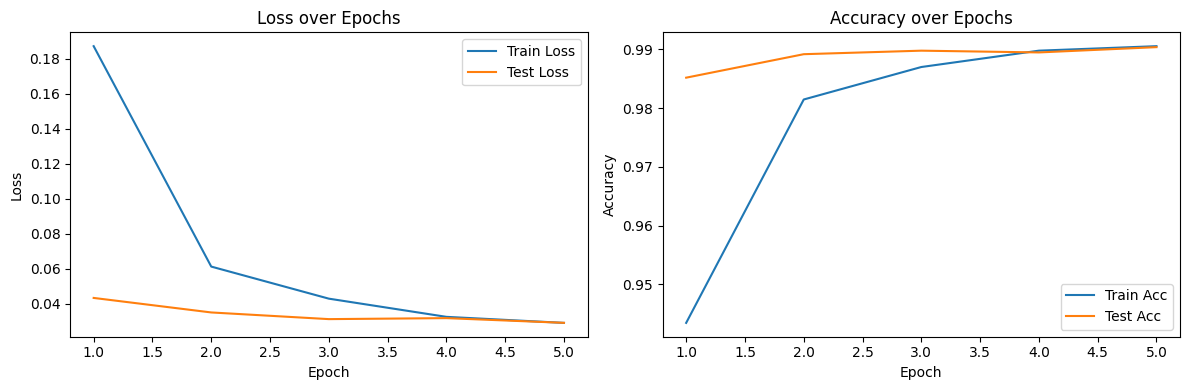

In [ ]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label="Train Loss")
plt.plot(epochs, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss over Epochs")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, train_accs, label="Train Acc")
plt.plot(epochs, test_accs, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy over Epochs")
plt.legend()

plt.tight_layout()
plt.show()

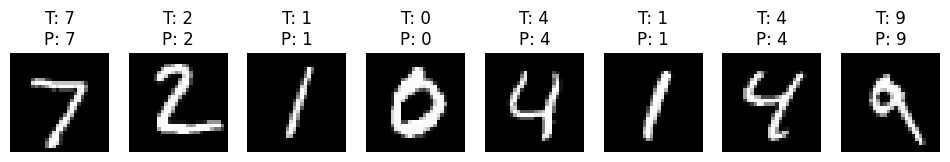

In [ ]:
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

images_cpu = images.cpu().squeeze(1).numpy()

n = 8
plt.figure(figsize=(12, 2))
for i in range(n):
    plt.subplot(1, n, i+1)
    plt.imshow(images_cpu[i], cmap="gray")
    plt.title(f"T: {labels[i].item()}\nP: {preds[i].item()}")
    plt.axis("off")
plt.show()

### What You Learned



One of the ways I learned how CNNs operate was through making a CNN for digit recognition. In a nutshell, convolution layers detect features in pictures, pooling layers reduce them, and fully connected layers recognize them. I wrote a basic CNN in PyTorch, trained it on MNIST handwritten digits for 5 epochs, and achieved 99% accuracy!

In addition to that, I learned the process of loading image datasets, monitoring loss and accuracy during training, and visualizing predictions. Now I have a clear picture of how neural networks actually see and categorize images.

Possible Extensions

I may also add more layers or filters for better accuracy, use different optimizers such as SGD, or test with other datasets like Fashion, MNIST or CIFAR, 10. Another idea would be to add data augmentation (rotating/flipping images), visualize the filters learned, or create a web app where I can draw digits and get real, time predictions!

